### Podstawowe informacje

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/dataset_invoices.csv')

df.head()

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,document_create_date,due_in_date,invoice_currency,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,days_late,paid_late
0,U001,200769623,WAL-MAR corp,11.02.2020,2020,1930438491,25.01.2020,10.02.2020,USD,54273.28,26.01.2020,NAH4,1.930438e+09,0,1.0,1.0
1,U001,200980828,BEN E,08.08.2019,2019,1929646410,22.07.2019,11.08.2019,USD,79656.60,22.07.2019,NAD1,1.929646e+09,0,0.0,0.0
2,U001,200792734,MDV/ trust,30.12.2019,2019,1929873765,14.09.2019,29.09.2019,USD,2253.86,14.09.2019,NAA8,1.929874e+09,0,92.0,1.0
3,CA02,140105686,SYSC llc,NaN,2020,2960623488,30.03.2020,10.04.2020,CAD,3299.70,31.03.2020,CA10,2.960623e+09,1,NaN,NaN
4,U001,200769623,WAL-MAR foundation,25.11.2019,2019,1930147974,13.11.2019,28.11.2019,USD,33133.29,13.11.2019,NAH4,1.930148e+09,0,0.0,0.0


In [68]:
date_cols = [
    'document_create_date',
    'due_in_date',
    'clear_date',
    'baseline_create_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors='coerce'
    )

In [69]:
print('Liczba wierszy:', df.shape[0])
print('Liczba kolumn:', df.shape[1])

display(df.head())
display(df.dtypes)

Liczba wierszy: 50000
Liczba kolumn: 16


,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,document_create_date,due_in_date,invoice_currency,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,days_late,paid_late
0,U001,200769623,WAL-MAR corp,2020-02-11,2020,1930438491,2020-01-25,2020-02-10,USD,54273.28,2020-01-26,NAH4,1.930438e+09,0,1.0,1.0
1,U001,200980828,BEN E,2019-08-08,2019,1929646410,2019-07-22,2019-08-11,USD,79656.60,2019-07-22,NAD1,1.929646e+09,0,0.0,0.0
2,U001,200792734,MDV/ trust,2019-12-30,2019,1929873765,2019-09-14,2019-09-29,USD,2253.86,2019-09-14,NAA8,1.929874e+09,0,92.0,1.0
3,CA02,140105686,SYSC llc,NaT,2020,2960623488,2020-03-30,2020-04-10,CAD,3299.70,2020-03-31,CA10,2.960623e+09,1,NaN,NaN
4,U001,200769623,WAL-MAR foundation,2019-11-25,2019,1930147974,2019-11-13,2019-11-28,USD,33133.29,2019-11-13,NAH4,1.930148e+09,0,0.0,0.0


business_code                   object
cust_number                     object
name_customer                   object
clear_date              datetime64[ns]
buisness_year                    int64
doc_id                           int64
document_create_date    datetime64[ns]
due_in_date             datetime64[ns]
invoice_currency                object
total_open_amount              float64
baseline_create_date    datetime64[ns]
cust_payment_terms              object
invoice_id                     float64
isOpen                           int64
days_late                      float64
paid_late                      float64
dtype: object

In [70]:
quality = pd.DataFrame({
    'braki': df.isna().sum(),
    'braki_%': (df.isna().mean() * 100).round(2),
    'unikalne': df.nunique()
})

display(
    quality.sort_values(
        'braki_%',
        ascending=False
    )
)

print('Duplikaty całych wierszy:', df.duplicated().sum())
print('Duplikaty doc_id:', df['doc_id'].duplicated().sum())

,braki,braki_%,unikalne
clear_date,10000,20.00,403
days_late,10000,20.00,109
paid_late,10000,20.00,2
invoice_id,6,0.01,48833
business_code,0,0.00,6
cust_number,0,0.00,1099
name_customer,0,0.00,4197
buisness_year,0,0.00,2
doc_id,0,0.00,48839
document_create_date,0,0.00,507


Duplikaty całych wierszy: 1161
Duplikaty doc_id: 1161


Braki w clear_date, days_late i paid_late są spowodowane obecnością otwartych faktur i nie powinny byc uzupełniane.
W zbiorze występuje 1161 całkowicie zduplikowanych rekordów, powinny zostać usunięte, aby te same faktury nie były wielokrotnie uwzględniane.

### Analiza faktur i opóźnień

In [71]:
status = df['isOpen'].value_counts().sort_index()

status.index = [
    'zamknięte' if value == 0 else 'otwarte'
    for value in status.index
]

display(status)

zamknięte    40000
otwarte      10000
Name: count, dtype: int64

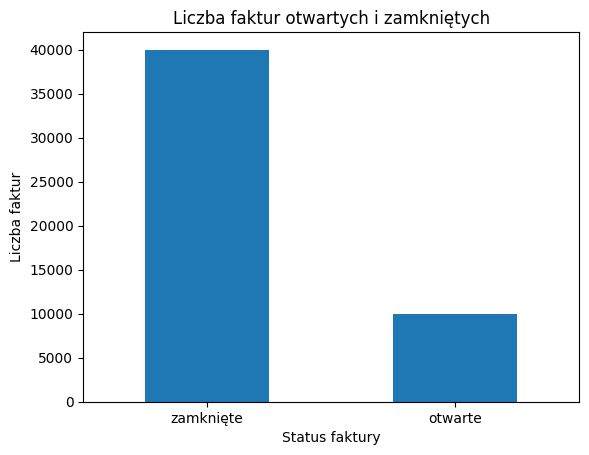

In [72]:
status.plot(kind='bar')

plt.title('Liczba faktur otwartych i zamkniętych')
plt.xlabel('Status faktury')
plt.ylabel('Liczba faktur')
plt.xticks(rotation=0)
plt.show()

,liczba,procent
terminowa,23236,58.09
opóźniona,16764,41.91


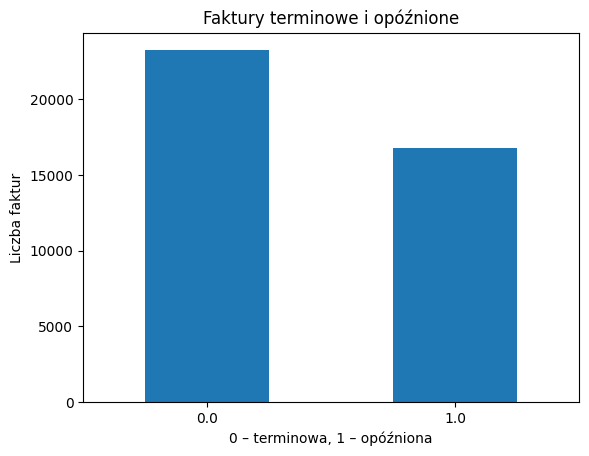

In [ ]:
closed = df[df['isOpen'] == 0].copy()

print(
    'Liczba zamkniętych faktur:',
    len(closed)
)

target_summary = pd.DataFrame({
    'liczba': closed['paid_late'].value_counts().sort_index(),
    'procent': (
        closed['paid_late']
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_summary.index = [
    'terminowa',
    'opóźniona'
]

display(target_summary)

closed['paid_late'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Faktury terminowe i opóźnione')
plt.xlabel('0 – terminowa, 1 – opóźniona')
plt.ylabel('Liczba faktur')
plt.xticks(rotation=0)
plt.show()

Zmienna docelowa jest stosunkowo dobrze zbalansowana. Udział opóźnionych faktur wynosi 41,91%, dlatego nie ma konieczności stosowania silnych metod równoważenia klas. Oprócz accuracy należy jednak oceniać model za pomocą recall, F1-score, ROC-AUC i PR-AUC, ponieważ szczególnie istotne jest wykrywanie faktur zagrożonych opóźnieniem.

count    40000.000000
mean         2.708500
std          9.096364
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
90%          5.000000
95%         10.000000
99%         50.000000
max        204.000000
Name: days_late, dtype: float64

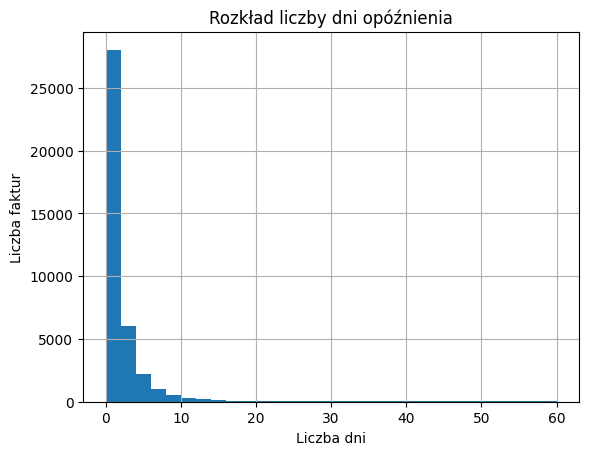

In [74]:
display(
    closed['days_late'].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

closed.loc[
    closed['days_late'] <= 60,
    'days_late'
].hist(bins=30)

plt.title('Rozkład liczby dni opóźnienia')
plt.xlabel('Liczba dni')
plt.ylabel('Liczba faktur')
plt.show()

Większość faktur jest opłacana terminowo lub z niewielkim opóźnieniem, jednak występują również pojedyncze bardzo długie opóźnienia. Rozkład  jest silnie prawostronnie skośny, dlatego sama średnia nie opisuje go wystarczająco dobrze. W regresji warto raportować MAE i błąd medianowy, ponieważ RMSE będzie silnie zależne od skrajnych opóźnień.

### Analiza kwot, terminów i klientów

count     50000.000000
mean      32337.021651
std       39205.975231
min           0.720000
25%        4928.312500
50%       17609.010000
75%       47133.635000
90%       82569.447000
95%      110843.717500
99%      163871.724400
max      668593.360000
Name: total_open_amount, dtype: float64

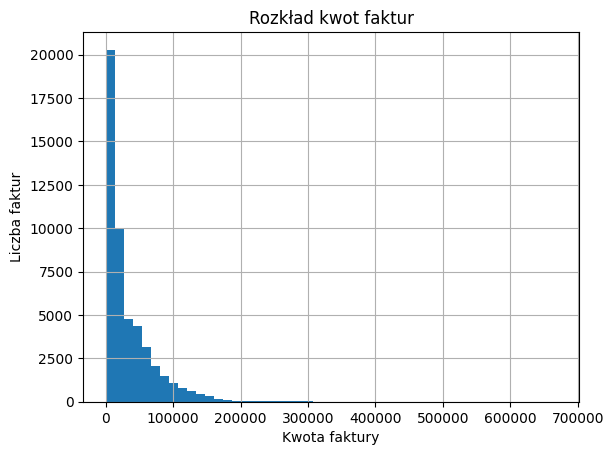

In [75]:
display(
    df['total_open_amount'].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

df['total_open_amount'].hist(bins=50)

plt.title('Rozkład kwot faktur')
plt.xlabel('Kwota faktury')
plt.ylabel('Liczba faktur')
plt.show()

Rozkład wartości faktur jest wyraźnie prawostronnie skośny i zawiera wysokie wartości odstające. Do opisu typowej faktury bardziej odpowiednia jest mediana niż średnia. Przed zastosowaniem regresji logistycznej warto rozważyć transformację log1p kwoty, aby ograniczyć wpływ największych faktur.

,liczba_faktur,srednia_kwota,mediana_kwoty
terminowa,23236,30593.94,16419.39
opóźniona,16764,34104.07,18561.10


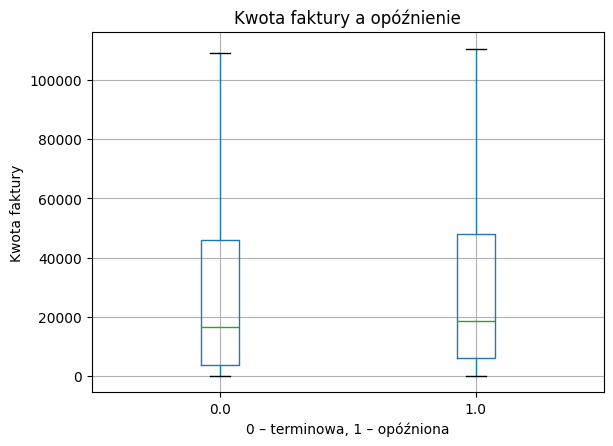

In [76]:
amount_by_target = (
    closed.groupby('paid_late')
    .agg(
        liczba_faktur=('doc_id', 'count'),
        srednia_kwota=('total_open_amount', 'mean'),
        mediana_kwoty=('total_open_amount', 'median')
    )
    .round(2)
)

amount_by_target.index = [
    'terminowa',
    'opóźniona'
]

display(amount_by_target)

closed.boxplot(
    column='total_open_amount',
    by='paid_late',
    showfliers=False
)

plt.title('Kwota faktury a opóźnienie')
plt.suptitle('')
plt.xlabel('0 – terminowa, 1 – opóźniona')
plt.ylabel('Kwota faktury')
plt.show()

Opóźnione faktury mają przeciętnie nieco większą wartość niż faktury terminowe. Różnica jest widoczna zarówno dla średniej, jak i mediany, ale silne nakładanie się rozkładów wskazuje, że kwota faktury nie będzie wystarczającym predyktorem samodzielnie. Może jednak stanowić użyteczną cechę w połączeniu z historią klienta i warunkami płatności.

In [77]:
df['payment_term_days'] = (
    df['due_in_date'] - df['document_create_date']
).dt.days

closed['payment_term_days'] = (
    closed['due_in_date'] -
    closed['document_create_date']
).dt.days

display(
    df['payment_term_days'].describe()
)

payment_terms_summary = (
    closed.groupby('paid_late')
    .agg(
        liczba_faktur=('doc_id', 'count'),
        sredni_termin=('payment_term_days', 'mean'),
        mediana_terminu=('payment_term_days', 'median'),
        srednie_opoznienie=('days_late', 'mean')
    )
    .round(2)
)

payment_terms_summary.index = [
    'terminowa',
    'opóźniona'
]

display(payment_terms_summary)

count    50000.000000
mean        17.924740
std         10.483327
min        -50.000000
25%         15.000000
50%         16.000000
75%         17.000000
max        122.000000
Name: payment_term_days, dtype: float64

,liczba_faktur,sredni_termin,mediana_terminu,srednie_opoznienie
terminowa,23236,18.16,16.0,0.00
opóźniona,16764,17.89,16.0,6.46


Typowy termin płatności wynosi około 16–18 dni i nie różni się istotnie między fakturami terminowymi a opóźnionymi. Sama długość terminu prawdopodobnie nie będzie silną cechą predykcyjną. Wartości ujemne oraz bardzo wysokie wymagają osobnej weryfikacji przed modelowaniem, ponieważ mogą oznaczać błędy lub nietypowe dokumenty.

In [78]:
df.loc[
    (df['payment_term_days'] < 0),
    [
        'document_create_date',
        'due_in_date',
        'payment_term_days',
        'doc_id'
    ]
].head(20)

,document_create_date,due_in_date,payment_term_days,doc_id
183,2019-03-25,2019-03-23,-2,1929024479
412,2019-02-01,2018-12-29,-34,1928721098
627,2020-04-27,2020-04-15,-12,1930830032
679,2019-10-31,2019-10-12,-19,1930070263
727,2019-10-26,2019-10-25,-1,1930050143
816,2019-02-13,2019-02-08,-5,1928793439
1418,2019-03-04,2019-03-03,-1,1928871409
1571,2019-08-02,2019-08-01,-1,1929690805
1635,2019-10-13,2019-10-11,-2,1930006533
1774,2020-03-24,2020-03-23,-1,1930691960


In [79]:
print(
    'Liczba klientów:',
    df['cust_number'].nunique()
)

customer_stats = (
    closed.groupby('cust_number')
    .agg(
        liczba_faktur=('doc_id', 'count'),
        udzial_opoznionych=('paid_late', 'mean'),
        srednie_opoznienie=('days_late', 'mean'),
        srednia_kwota=('total_open_amount', 'mean')
    )
)

customer_stats['udzial_opoznionych'] = (
    customer_stats['udzial_opoznionych'] * 100
)

customer_stats = customer_stats.sort_values(
    'liczba_faktur',
    ascending=False
)

display(customer_stats.head(10).round(2))

Liczba klientów: 1099


,liczba_faktur,udzial_opoznionych,srednie_opoznienie,srednia_kwota
cust_number,,,,
200769623,9581,17.58,0.75,22583.26
200726979,1612,43.92,1.34,3665.71
200762301,1225,34.29,0.93,49366.53
200759878,1144,77.36,1.59,34968.89
200794332,995,22.51,0.82,24300.89
200744019,851,63.81,2.83,24434.38
200772670,739,64.01,2.00,43516.90
200705742,695,10.65,0.24,25953.35
200707822,560,40.36,1.04,73110.21


Historia klienta jest prawdopodobnie jedną z najważniejszych informacji predykcyjnych. Klienci znacząco różnią się udziałem opóźnionych płatności i długością opóźnień. Dane są jednocześnie skoncentrowane wokół kilku dużych klientów, dlatego wyniki modelu mogą być zdominowane przez najczęściej występujące podmioty.

In [80]:
currency_summary = (
    closed.groupby('invoice_currency')
    .agg(
        liczba_faktur=('doc_id', 'count'),
        udzial_opoznionych=('paid_late', 'mean'),
        srednie_opoznienie=('days_late', 'mean')
    )
)

currency_summary['udzial_opoznionych'] *= 100

display(currency_summary.round(2))

business_summary = (
    closed.groupby('business_code')
    .agg(
        liczba_faktur=('doc_id', 'count'),
        udzial_opoznionych=('paid_late', 'mean'),
        srednie_opoznienie=('days_late', 'mean')
    )
)

business_summary['udzial_opoznionych'] *= 100

display(
    business_summary
    .sort_values('liczba_faktur', ascending=False)
    .round(2)
)

,liczba_faktur,udzial_opoznionych,srednie_opoznienie
invoice_currency,,,
CAD,3182,74.83,6.91
USD,36818,39.07,2.35


,liczba_faktur,udzial_opoznionych,srednie_opoznienie
business_code,,,
U001,36190,38.66,2.22
CA02,3180,74.84,6.91
U013,501,58.08,10.93
U002,116,76.72,4.60
U005,9,88.89,8.89
U007,4,100.00,6.25


In [81]:
pd.crosstab(
    df['business_code'],
    df['invoice_currency']
)

invoice_currency,CAD,USD
business_code,,
CA02,3917,0
U001,0,45359
U002,0,135
U005,0,11
U007,0,5
U013,2,571


Waluta i kod biznesowy wykazują silny związek z opóźnieniem płatności. Faktury w CAD oraz z kodem CA02 są znacznie częściej opóźniane niż faktury w USD i z kodem U001. 
Waluta faktury jest niemal całkowicie zależna od kodu biznesowego. Kod CA02 występuje wyłącznie dla faktur w CAD, natomiast większość pozostałych kodów występuje wyłącznie w USD. Oznacza to, że różnice w opóźnieniach obserwowane dla walut i kodów biznesowych opisują w dużej mierze ten sam podział danych.

### Analiza czasowa

,liczba_faktur,udzial_opoznionych,srednie_opoznienie,laczna_kwota
year_month,,,,
2018-12,193,34.72,3.77,4.562943e+06
2019-01,2707,44.37,3.32,8.615498e+07
2019-02,2752,44.55,3.18,8.468967e+07
2019-03,3252,41.24,3.10,9.997271e+07
2019-04,3189,41.86,3.21,9.863880e+07
2019-05,3030,41.65,2.47,9.554686e+07
2019-06,3043,43.15,2.85,9.878801e+07
2019-07,3021,42.93,2.89,8.987457e+07
2019-08,3123,43.16,2.66,1.039319e+08


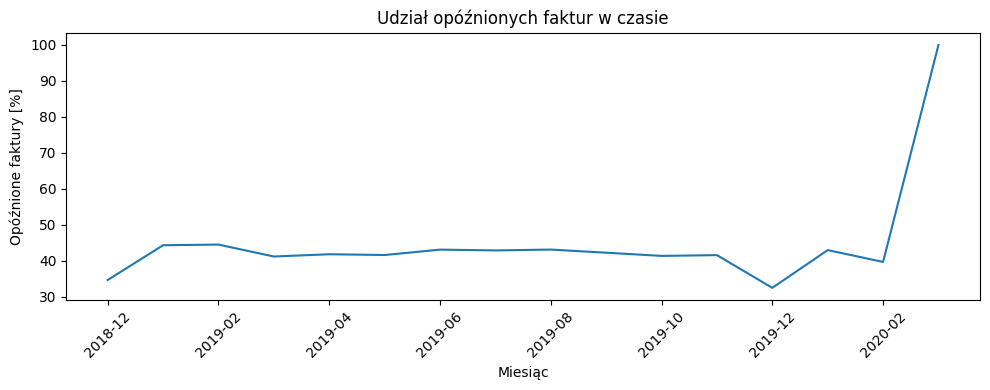

In [82]:
closed['year_month'] = (
    closed['document_create_date']
    .dt.to_period('M')
    .astype(str)
)

monthly = (
    closed.groupby('year_month')
    .agg(
        liczba_faktur=('doc_id', 'count'),
        udzial_opoznionych=('paid_late', 'mean'),
        srednie_opoznienie=('days_late', 'mean'),
        laczna_kwota=('total_open_amount', 'sum')
    )
)

monthly['udzial_opoznionych'] *= 100

display(monthly.round(2))

monthly['udzial_opoznionych'].plot(figsize=(10, 4))

plt.title('Udział opóźnionych faktur w czasie')
plt.xlabel('Miesiąc')
plt.ylabel('Opóźnione faktury [%]')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

W większości pełnych miesięcy udział opóźnionych faktur jest względnie stabilny i wynosi około 40–45%. Widoczne są jednak zmiany średniej długości opóźnienia oraz nietypowe wyniki w miesiącach granicznych. Grudzień 2018 i marzec 2020 zawierają zbyt mało obserwacji, aby wyciągać z nich wiarygodne wnioski. Dane mają charakter czasowy, dlatego model powinien być walidowany na późniejszym okresie, a nie przy użyciu wyłącznie losowego podziału.